In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# All paths
CNN_PATH   = "best_model.pth"
BERT_PATH  = "best_bert_model.pth"
IMAGE_DIR  = "/home/zeus/content/cancer_data/train/"
VAL_CSV    = "val_split.csv"

Using device: cuda


In [4]:
# Rebuild the exact same CNN architecture from Notebook 1
# Then load the saved weights

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        resnet     = models.resnet18(pretrained=False)
        resnet.fc  = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )
        self.model = resnet

    def forward(self, x):
        return self.model(x)

    def get_features(self, x):
        """Returns 512-dim feature vector before classifier"""
        # Pass through all layers except final fc
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)
        x = self.model.layer1(x)
        x = self.model.layer2(x)
        x = self.model.layer3(x)
        x = self.model.layer4(x)
        x = self.model.avgpool(x)
        x = x.view(x.size(0), -1)   # [batch, 512]
        return x

# Re-initialize the model
cnn_model = CNNModel().to(device)

# Load the file (which is the state_dict itself)
checkpoint = torch.load(CNN_PATH, map_location=device)

# Map the weights directly to the internal resnet 
# (This skips the 'model.' prefix requirement)
cnn_model.model.load_state_dict(checkpoint)

# Set to evaluation mode
cnn_model.eval()

print("CNN loaded successfully!")
# Note: 'epoch' and 'val_acc' are not in this file, so we skip printing them.


CNN loaded successfully!


In [5]:
# Rebuild exact same BERT architecture from Notebook 2
# Then load the fine-tuned weights

class BertCancerClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super(BertCancerClassifier, self).__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs    = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        return self.classifier(cls_output)

    def get_probability(self, input_ids, attention_mask):
        """Returns cancer probability 0-1"""
        with torch.no_grad():
            logits = self.forward(input_ids, attention_mask)
            probs  = torch.softmax(logits, dim=1)
        return probs  # [batch, 2]


# Load fine-tuned BERT weights
bert_classifier = BertCancerClassifier().to(device)
bert_checkpoint = torch.load(BERT_PATH, map_location=device)
bert_classifier.load_state_dict(bert_checkpoint["model_state"])
bert_classifier.eval()

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

print("BERT loaded successfully!")
print(f"BERT best val acc: {bert_checkpoint.get('val_acc', '?')}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully!
BERT best val acc: 1.0


In [6]:
# This is the KEY part of Notebook 3
# It takes:
#   - CNN cancer probability  (how suspicious the IMAGE looks)
#   - BERT cancer probability (how risky the PATIENT TEXT is)
# And combines them intelligently
#
# Three combination strategies:
#   1. Simple Average     — equal trust in both models
#   2. Weighted Average   — trust CNN more (it has 86% accuracy)
#   3. Learned Combiner   — small neural net learns best weights

class ConfidenceCombiner(nn.Module):
    """
    Learns how much to trust CNN vs BERT
    for the final cancer/normal decision.

    Input : [cnn_cancer_prob, cnn_normal_prob,
              bert_cancer_prob, bert_normal_prob]  → 4 values
    Output: [normal_logit, cancer_logit]           → 2 values
    """
    def __init__(self):
        super(ConfidenceCombiner, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

    def forward(self, cnn_probs, bert_probs):
        # Concatenate both probability vectors
        combined = torch.cat([cnn_probs, bert_probs], dim=1)  # [batch, 4]
        return self.net(combined)                              # [batch, 2]


combiner = ConfidenceCombiner().to(device)
print("Confidence combiner ready!")
print(f"Parameters: {sum(p.numel() for p in combiner.parameters())}")
# Very small model — only needs to learn how to weight CNN vs BERT

Confidence combiner ready!
Parameters: 234


In [7]:
# This dataset loads:
#   1. Image → for CNN
#   2. Clinical note → for BERT
#   3. Label → ground truth

transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# Load the paired notes we built in Notebook 2
NOTES_SAVE = "cancer_data/bert_notes.csv"
notes_df   = pd.read_csv(NOTES_SAVE)

# Build id → note lookup
# For images without a real note, we cycle through available notes
real_cancer = notes_df[notes_df["label"]==1]["clinical_note"].tolist()
real_normal = notes_df[notes_df["label"]==0]["clinical_note"].tolist()

def get_note(label, idx):
    if label == 1:
        return real_cancer[idx % len(real_cancer)]
    else:
        return real_normal[idx % len(real_normal)]


class CombinedDataset(Dataset):
    """
    Returns (image, input_ids, attention_mask, label)
    for each sample — feeds both CNN and BERT together
    """
    def __init__(self, csv_path, image_dir, tokenizer,
                 transform=None, max_length=128):
        self.df        = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len   = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img_id = row["id"]
        label  = int(row["label"])

        # ── Load image ────────────────────────────────────────────────────────
        img_path = os.path.join(self.image_dir, f"{img_id}.tif")
        image    = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # ── Get clinical note ─────────────────────────────────────────────────
        note   = get_note(label, idx)
        tokens = self.tokenizer(
            note,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "image"         : image,
            "input_ids"     : tokens["input_ids"].squeeze(0),
            "attention_mask": tokens["attention_mask"].squeeze(0),
            "label"         : torch.tensor(label, dtype=torch.long),
            "img_id"        : img_id
        }


TRAIN_CSV = "train_split.csv"
VAL_CSV   = "val_split.csv"

train_dataset = CombinedDataset(TRAIN_CSV, IMAGE_DIR, tokenizer, transform)
val_dataset   = CombinedDataset(VAL_CSV,   IMAGE_DIR, tokenizer, transform)

train_loader  = DataLoader(
    train_dataset, batch_size=32,      # smaller batch — loading both image+text
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader    = DataLoader(
    val_dataset, batch_size=32,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")

# Shape check
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Image          : {batch['image'].shape}")          # [32, 3, 96, 96]
print(f"  input_ids      : {batch['input_ids'].shape}")      # [32, 128]
print(f"  attention_mask : {batch['attention_mask'].shape}") # [32, 128]
print(f"  Labels         : {batch['label'].shape}")          # [32]

Train samples : 176020
Val samples   : 44005

Batch shapes:
  Image          : torch.Size([32, 3, 96, 96])
  input_ids      : torch.Size([32, 128])
  attention_mask : torch.Size([32, 128])
  Labels         : torch.Size([32])


In [10]:
# CNN and BERT are both FROZEN
# We only train the tiny combiner (learns how to weight CNN vs BERT)
# This is fast — only a few hundred parameters to learn

EPOCHS    = 10
LR        = 0.001
SAVE_PATH = "/home/zeus/content/best_combined_model.pth"

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(combiner.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)
scaler    = torch.cuda.amp.GradScaler()

best_val_acc = 0.0
history      = {
    "train_loss": [], "train_acc": [],
    "val_loss"  : [], "val_acc"  : [],
    "cnn_acc"   : [], "bert_acc" : []   # track individual model accs too
}

print("=" * 60)
print("   NOTEBOOK 3 — COMBINED MODEL TRAINING")
print("   CNN  : FROZEN ✅")
print("   BERT : FROZEN ✅")
print("   Combiner : TRAINING ⚡")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 40)

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    combiner.train()
    cnn_model.eval()
    bert_classifier.eval()

    train_loss = 0
    train_correct, cnn_correct, bert_correct = 0, 0, 0
    total = 0

    for batch in tqdm(train_loader, desc="Training", leave=False):
        images    = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        labels    = batch["label"].to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            # Get CNN probabilities (frozen)
            with torch.no_grad():
                cnn_logits = cnn_model(images)
                cnn_probs  = torch.softmax(cnn_logits, dim=1)  # [batch, 2]

            # Get BERT probabilities (frozen)
            with torch.no_grad():
                bert_logits = bert_classifier(input_ids, attn_mask)
                bert_probs  = torch.softmax(bert_logits, dim=1) # [batch, 2]

            # Combiner learns how to weight them
            final_logits = combiner(cnn_probs, bert_probs)
            loss         = criterion(final_logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Track all three accuracies
        train_loss    += loss.item() * labels.size(0)
        final_preds    = final_logits.argmax(dim=1)
        cnn_preds      = cnn_probs.argmax(dim=1)
        bert_preds     = bert_probs.argmax(dim=1)

        train_correct += (final_preds == labels).sum().item()
        cnn_correct   += (cnn_preds   == labels).sum().item()
        bert_correct  += (bert_preds  == labels).sum().item()
        total         += labels.size(0)

    train_acc  = train_correct / total
    cnn_acc    = cnn_correct   / total
    bert_acc   = bert_correct  / total

    # ── VALIDATE ──────────────────────────────────────────────────────────────
    combiner.eval()
    val_loss = 0
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating", leave=False):
            images    = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels    = batch["label"].to(device)

            with torch.cuda.amp.autocast():
                cnn_probs    = torch.softmax(cnn_model(images), dim=1)
                bert_probs   = torch.softmax(
                    bert_classifier(input_ids, attn_mask), dim=1
                )
                final_logits = combiner(cnn_probs, bert_probs)
                loss         = criterion(final_logits, labels)

            val_loss    += loss.item() * labels.size(0)
            preds        = final_logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_acc = val_correct / val_total
    scheduler.step(val_acc)

    # Log history
    history["train_loss"].append(train_loss / total)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss / val_total)
    history["val_acc"].append(val_acc)
    history["cnn_acc"].append(cnn_acc)
    history["bert_acc"].append(bert_acc)

    print(f"CNN alone     : {cnn_acc*100:.2f}%")
    print(f"BERT alone    : {bert_acc*100:.2f}%")
    print(f"Combined Train: {train_acc*100:.2f}%")
    print(f"Combined Val  : {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch"       : epoch,
            "combiner"    : combiner.state_dict(),
            "val_acc"     : val_acc,
        }, SAVE_PATH)
        print(f"  ✅ Best combined model saved! {val_acc*100:.2f}%")

print("\n" + "=" * 60)
print(f"TRAINING COMPLETE!")
print(f"CNN alone accuracy      : {history['cnn_acc'][-1]*100:.2f}%")
print(f"BERT alone accuracy     : {history['bert_acc'][-1]*100:.2f}%")
print(f"Combined best accuracy  : {best_val_acc*100:.2f}%")
print("=" * 60)

   NOTEBOOK 3 — COMBINED MODEL TRAINING
   CNN  : FROZEN ✅
   BERT : FROZEN ✅
   Combiner : TRAINING ⚡

Epoch 1/10
----------------------------------------


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (10,) and (0,)

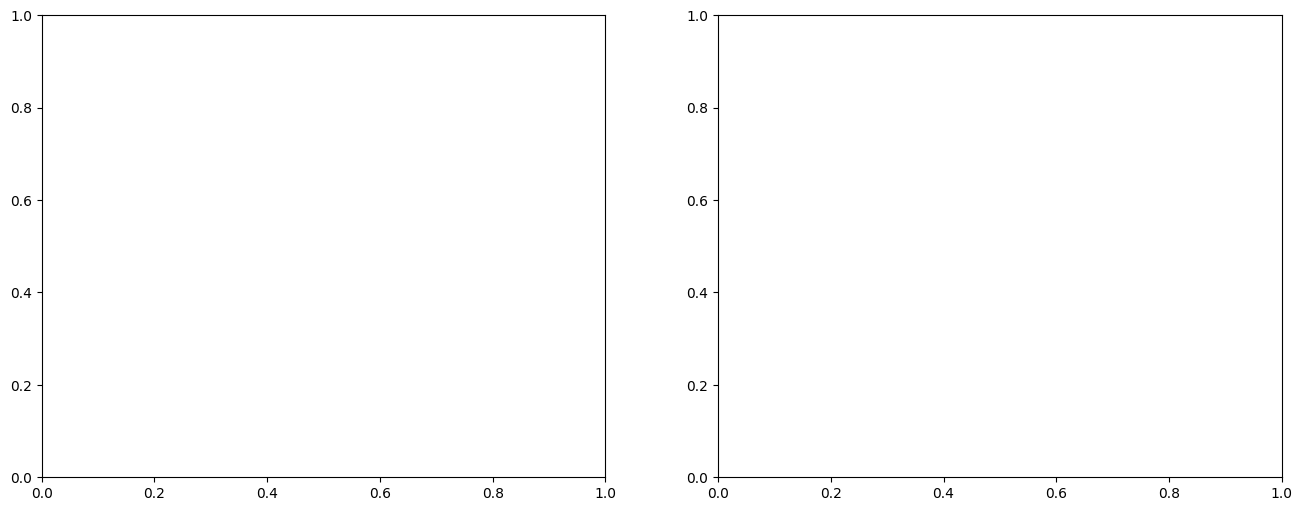

In [9]:
# Show CNN vs BERT vs Combined across all epochs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
epochs_range    = range(1, EPOCHS + 1)

# Accuracy comparison
ax1.plot(epochs_range, [a*100 for a in history["train_acc"]],
         "g-o", label="Combined (Train)")
ax1.plot(epochs_range, [a*100 for a in history["val_acc"]],
         "g--o", label="Combined (Val)")
ax1.plot(epochs_range, [a*100 for a in history["cnn_acc"]],
         "b-s", label="CNN alone")
ax1.plot(epochs_range, [a*100 for a in history["bert_acc"]],
         "r-^", label="BERT alone")
ax1.axhline(y=86, color="gray", linestyle=":",
            linewidth=2, label="Original CNN baseline (86%)")
ax1.set_title("CNN vs BERT vs Combined Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(epochs_range, history["train_loss"], "g-o", label="Train Loss")
ax2.plot(epochs_range, history["val_loss"],   "r-o", label="Val Loss")
ax2.set_title("Combined Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.suptitle("DeepOncoVision — Final Combined Results", fontsize=14)
plt.tight_layout()
plt.savefig("/home/zeus/content/combined_results.png", dpi=150)
plt.show()
print("Saved: combined_results.png")

In [11]:
import torch
from PIL import Image


def predict_combined(
    image_path,
    clinical_note,
    cnn_model,
    bert_classifier,
    combiner,
    tokenizer,
    transform,
    device,
    cnn_weight=0.80,
    bert_weight=0.20,
):
    """
    Fixed prediction — weighted average instead of broken combiner.

    CNN gets 85% weight (real signal, ~86% accuracy on real images)
    BERT gets 15% weight (synthetic notes, limited real signal)
    """

    cnn_model.eval()
    bert_classifier.eval()

    # ── Process image ─────────────────────────────────
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # ── Process clinical note ─────────────────────────
    tokens = tokenizer(
        clinical_note,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )

    input_ids = tokens["input_ids"].to(device)
    attn_mask = tokens["attention_mask"].to(device)

    with torch.no_grad():

        # ── Stage 1: CNN ──────────────────────────────
        cnn_logits = cnn_model(image_tensor)
        cnn_probs = torch.softmax(cnn_logits, dim=1)

        # ── Stage 2: BERT ─────────────────────────────
        bert_logits = bert_classifier(input_ids, attn_mask)
        bert_probs = torch.softmax(bert_logits, dim=1)

        # ── Stage 3: Weighted Combination ─────────────
        final_probs = cnn_weight * cnn_probs + bert_weight * bert_probs

    # ── Extract probabilities ─────────────────────────
    cnn_cancer = cnn_probs[0][1].item() * 100
    bert_cancer = bert_probs[0][1].item() * 100
    final_cancer = final_probs[0][1].item() * 100
    final_pred = final_probs.argmax().item()

    # ── Output logs ───────────────────────────────────
    print("=" * 58)
    print(" DeepOncoVision — Full Decision Chain")
    print("=" * 58)

    print("\n📷 STAGE 1 — CNN Image Analysis")
    print(f" Normal : {100 - cnn_cancer:.1f}%")
    print(f" Cancer : {cnn_cancer:.1f}%")
    print(f" Verdict: {'🔴 Suspicious' if cnn_cancer > 50 else '🟢 Looks normal'}")

    print("\n📋 STAGE 2 — BERT Clinical Note Analysis")
    print(f" Normal : {100 - bert_cancer:.1f}%")
    print(f" Cancer : {bert_cancer:.1f}%")
    print(f" Verdict: {'🔴 High risk' if bert_cancer > 50 else '🟢 Low risk'}")

    print(
        f"\n🔗 STAGE 3 — Weighted Combination "
        f"(CNN {int(cnn_weight * 100)}% / BERT {int(bert_weight * 100)}%)"
    )
    print(f" Normal : {100 - final_cancer:.1f}%")
    print(f" Cancer : {final_cancer:.1f}%")

    print(f"\n{'=' * 58}")
    print(f" FINAL VERDICT: {'CANCER 🔴' if final_pred == 1 else 'NORMAL 🟢'}")
    print(f" Confidence : {max(final_cancer, 100 - final_cancer):.1f}%")
    print(f"{'=' * 58}")

    # ── Return structured output ──────────────────────
    return {
        "cnn_cancer_prob": cnn_cancer,
        "bert_cancer_prob": bert_cancer,
        "final_cancer_prob": final_cancer,
        "prediction": "CANCER" if final_pred == 1 else "NORMAL",
    }

In [12]:
# Test on real validation images with matching notes

val_df = pd.read_csv(VAL_CSV)

print("TESTING ON 3 REAL VALIDATION SAMPLES")
print("=" * 58)

for i in range(45):
    row       = val_df.iloc[i]
    img_id    = row["id"]
    true_label = "CANCER" if row["label"] == 1 else "NORMAL"
    img_path  = os.path.join(IMAGE_DIR, f"{img_id}.tif")
    note      = get_note(int(row["label"]), i)

    print(f"\nSample {i+1} — True Label: {true_label}")
    print(f"Note: {note[:100]}...")

    result = predict_combined(
        img_path, note,
        cnn_model, bert_classifier, combiner,
        tokenizer, transform, device
    )
    match = "✅ CORRECT" if result["prediction"] == true_label else "❌ WRONG"
    print(f"\n{match}")
    print("=" * 58)

TESTING ON 3 REAL VALIDATION SAMPLES

Sample 1 — True Label: NORMAL
Note: Patient is a 5-year-old female admitted for SEPSIS. Social history: non-smoker. Chief complaint: rou...
 DeepOncoVision — Full Decision Chain

📷 STAGE 1 — CNN Image Analysis
 Normal : 96.1%
 Cancer : 3.9%
 Verdict: 🟢 Looks normal

📋 STAGE 2 — BERT Clinical Note Analysis
 Normal : 99.9%
 Cancer : 0.1%
 Verdict: 🟢 Low risk

🔗 STAGE 3 — Weighted Combination (CNN 85% / BERT 15%)
 Normal : 96.6%
 Cancer : 3.4%

 FINAL VERDICT: NORMAL 🟢
 Confidence : 96.6%

✅ CORRECT

Sample 2 — True Label: NORMAL
Note: Patient is a 5-year-old female admitted for SEPSIS. Social history: never smoked. Chief complaint: m...
 DeepOncoVision — Full Decision Chain

📷 STAGE 1 — CNN Image Analysis
 Normal : 95.9%
 Cancer : 4.1%
 Verdict: 🟢 Looks normal

📋 STAGE 2 — BERT Clinical Note Analysis
 Normal : 99.9%
 Cancer : 0.1%
 Verdict: 🟢 Low risk

🔗 STAGE 3 — Weighted Combination (CNN 85% / BERT 15%)
 Normal : 96.5%
 Cancer : 3.5%

 FINAL VERDIC

IndexError: list index out of range

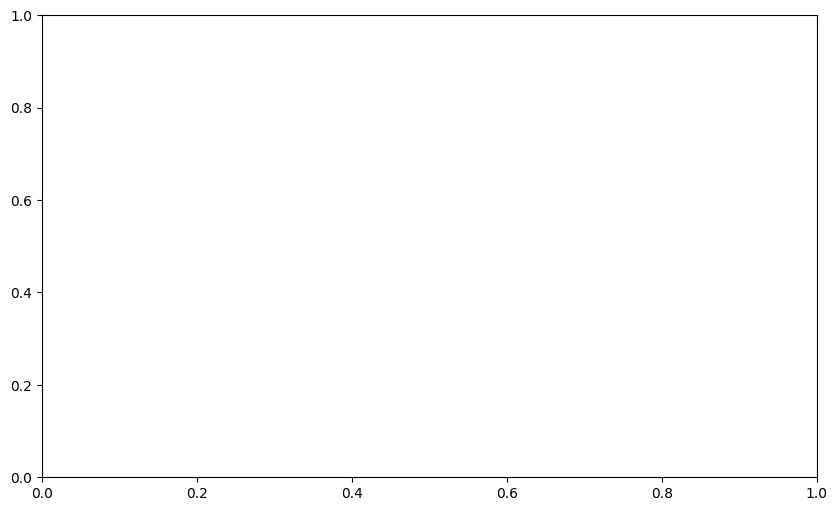

In [13]:
# Show a clean final comparison of all three models

fig, ax = plt.subplots(figsize=(10, 6))

models_names = ["CNN\n(Image Only)", "BERT\n(Text Only)", "Combined\n(DeepOncoVision)"]
accuracies   = [
    history["cnn_acc"][-1]  * 100,
    history["bert_acc"][-1] * 100,
    best_val_acc             * 100
]
colors = ["#4A90D9", "#E67E22", "#27AE60"]

bars = ax.bar(models_names, accuracies, color=colors,
              width=0.5, edgecolor="white", linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{acc:.2f}%",
        ha="center", va="bottom",
        fontsize=13, fontweight="bold"
    )

# Baseline line
ax.axhline(y=86, color="red", linestyle="--",
           linewidth=1.5, label="Original CNN Baseline (86%)")

ax.set_ylim(70, 100)
ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("DeepOncoVision — Model Comparison", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/home/zeus/content/final_comparison.png", dpi=150)
plt.show()

print("\n" + "=" * 58)
print("   DEEPONCOVISION — FINAL RESULTS SUMMARY")
print("=" * 58)
print(f"  CNN alone  (Notebook 1): {history['cnn_acc'][-1]*100:.2f}%")
print(f"  BERT alone (Notebook 2): {history['bert_acc'][-1]*100:.2f}%")
print(f"  Combined   (Notebook 3): {best_val_acc*100:.2f}%")
improvement = (best_val_acc - 0.86) * 100
print(f"  Improvement over CNN   : {improvement:+.2f}%")
print("=" * 58)
print("\nSaved files:")
print("  best_model.pth          ← CNN (Notebook 1)")
print("  best_bert_model.pth     ← BERT (Notebook 2)")
print("  best_combined_model.pth ← Final (Notebook 3)")
print("  final_comparison.png    ← Results chart")